# Portfolio Sizing Analysis

Sweeps a grid of fixed stock / bond / commodity-trend allocations and compares them on multiple risk-adjusted metrics (Sharpe, Calmar, Sortino, max drawdown) against the 60/40 baseline and Jimmy's dynamic mean-variance optimizer.

**Key question:** how much of the dynamic MV's benefit can a simple fixed blend capture, and which allocation wins across different yield-curve regimes?

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display

sys.path.insert(0, str(Path.cwd()))
from trend_analysis.metrics import drawdown, TRADING_DAYS
from trend_analysis.plots import apply_theme
apply_theme()

REGIME_DIR = Path('output/regime')
DATA_DIR   = Path('../data')
SIZING_DIR = Path('output/sizing')
SIZING_DIR.mkdir(parents=True, exist_ok=True)

REGIME_ORDER = [
    'Bull Steepener', 'Bull Flattener', 'Bear Steepener',
    'Bear Flattener', 'Steepener Twist', 'Flattener Twist'
]

In [2]:
daily = pd.read_csv('output/merged_method1_vs_60_40_daily.csv',
                    parse_dates=['Dates'], index_col='Dates')

regimes_raw = (pd.read_excel(DATA_DIR / 'interest_rate_regimes.xlsx',
                             parse_dates=['date'])
               .set_index('date')['regime_filtered'])

q3_dyn  = pd.read_csv(REGIME_DIR / 'q3_dynamic_weights_3asset.csv',
                      parse_dates=['date']).set_index('date')
q3_strat = pd.read_csv(REGIME_DIR / 'q3_strategies_summary.csv').set_index('Strategy')

eq_ret    = daily['spxt_return']
bond_ret  = daily['luattruu_return']
trend_ret = daily['method1_strategy_return']
bench_ret = daily['benchmark_strategy_return']

print(f'Date range: {daily.index.min().date()} to {daily.index.max().date()}')
print(f'N = {len(daily):,} trading days')

Date range: 2002-01-01 to 2026-04-20
N = 6,340 trading days


In [3]:
def compute_metrics(label, ret_series):
    """Ann. return, vol, Sharpe, max DD, Calmar, Sortino."""
    ret    = ret_series.dropna()
    wealth = (1 + ret).cumprod()
    years  = len(ret) / TRADING_DAYS
    ann_ret = wealth.iloc[-1] ** (1 / years) - 1
    ann_vol = ret.std() * np.sqrt(TRADING_DAYS)
    sharpe  = ann_ret / ann_vol if ann_vol else np.nan
    max_dd  = drawdown(ret).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    neg     = ret[ret < 0]
    sortino = ann_ret / (neg.std() * np.sqrt(TRADING_DAYS)) if len(neg) > 0 else np.nan
    return {'Label': label, 'Ann. Return': ann_ret, 'Ann. Vol': ann_vol,
            'Sharpe': sharpe, 'Max DD': max_dd, 'Calmar': calmar, 'Sortino': sortino}


def regime_sharpe(ret_series, regime_col):
    """Sharpe ratio within each named regime."""
    result = {}
    for regime in REGIME_ORDER:
        sub = ret_series[regime_col == regime].dropna()
        if len(sub) < 30:
            result[regime] = np.nan
            continue
        yrs   = len(sub) / TRADING_DAYS
        ann_r = (1 + sub).prod() ** (1 / yrs) - 1
        ann_v = sub.std() * np.sqrt(TRADING_DAYS)
        result[regime] = ann_r / ann_v if ann_v else np.nan
    return result

## Section 1 — Building the Blend Grid

Sweep stock% from 30–65, trend% from 0–40 (step 5), bond = remainder. Exclude blends where bond < 20%.

In [4]:
results, blend_rets = [], {}

for trend_pct in range(0, 45, 5):
    for stock_pct in range(30, 70, 5):
        bond_pct = 100 - stock_pct - trend_pct
        if bond_pct < 20:
            continue
        w_s, w_b, w_t = stock_pct / 100, bond_pct / 100, trend_pct / 100
        label = f'{stock_pct}/{bond_pct}/{trend_pct}'
        ret   = w_s * eq_ret + w_b * bond_ret + w_t * trend_ret
        m     = compute_metrics(label, ret)
        m.update({'Stock %': stock_pct, 'Bond %': bond_pct, 'Trend %': trend_pct})
        results.append(m)
        blend_rets[label] = ret

grid = pd.DataFrame(results).set_index('Label')
print(f'Total blends evaluated: {len(grid)}')
grid.sort_values('Sharpe', ascending=False).head(5)

Total blends evaluated: 57


,Ann. Return,Ann. Vol,Sharpe,Max DD,Calmar,Sortino,Stock %,Bond %,Trend %
Label,,,,,,,,,
30/55/15,0.055845,0.057584,0.969798,-0.155026,0.360227,1.264305,30,55,15
30/60/10,0.055189,0.056940,0.969245,-0.153203,0.360233,1.266699,30,60,10
30/50/20,0.056482,0.058525,0.965105,-0.162565,0.347444,1.255149,30,50,20
30/65/5,0.054515,0.056603,0.963102,-0.160998,0.338603,1.262189,30,65,5
30/45/25,0.057102,0.059748,0.955707,-0.170055,0.335783,1.240286,30,45,25


The top blends by Sharpe all have 30% stock not 60%. This could be due to the fact that the sample period captured the long bond bull market. Lower stock allocation resulted in lower volalility and bonds contribute strong risk adjusted returns throughout this window. This is a sample dependent result and not necessarily a forward looking recommendation.

In [11]:
grid.to_csv(SIZING_DIR / 'blend_grid_metrics.csv')

fmt = {'Ann. Return': '{:.1%}', 'Ann. Vol': '{:.1%}', 'Sharpe': '{:.2f}',
       'Max DD': '{:.1%}', 'Calmar': '{:.2f}', 'Sortino': '{:.2f}',
       'Stock %': '{:.0f}', 'Bond %': '{:.0f}', 'Trend %': '{:.0f}'}

display(grid.sort_values('Sharpe', ascending=False)
        [['Stock %', 'Bond %', 'Trend %', 'Ann. Return', 'Ann. Vol',
          'Sharpe', 'Max DD', 'Calmar', 'Sortino']]
        .head(20)
        .style.format(fmt)
        .set_caption('Top 20 Blends by Sharpe Ratio'))

,Stock %,Bond %,Trend %,Ann. Return,Ann. Vol,Sharpe,Max DD,Calmar,Sortino
Label,,,,,,,,,
30/55/15,30,55,15,5.6%,5.8%,0.97,-15.5%,0.36,1.26
30/60/10,30,60,10,5.5%,5.7%,0.97,-15.3%,0.36,1.27
30/50/20,30,50,20,5.6%,5.9%,0.97,-16.3%,0.35,1.26
30/65/5,30,65,5,5.5%,5.7%,0.96,-16.1%,0.34,1.26
30/45/25,30,45,25,5.7%,6.0%,0.96,-17.0%,0.34,1.24
30/70/0,30,70,0,5.4%,5.7%,0.95,-16.9%,0.32,1.25
30/40/30,30,40,30,5.8%,6.1%,0.94,-17.7%,0.33,1.22
30/35/35,30,35,35,5.8%,6.3%,0.93,-18.5%,0.32,1.20
30/30/40,30,30,40,5.9%,6.5%,0.91,-19.2%,0.31,1.17


Within the 30% stock tier, adding trend slightly improves Sharpe relative to 30/70/0 (pure bond-heavy):
- 30/70/0: Sharpe 0.951
- 30/60/10: Sharpe 0.969 (+0.018)
- 30/55/15: Sharpe 0.970 (+0.019)

Trend's marginal contribution is real but small. The bond allocation seems to be doing most of the Sharpe heavy lifting. 

## Section 2 — Efficient Frontier

Each dot is one blend. Stars mark reference strategies. Color encodes Sharpe ratio.

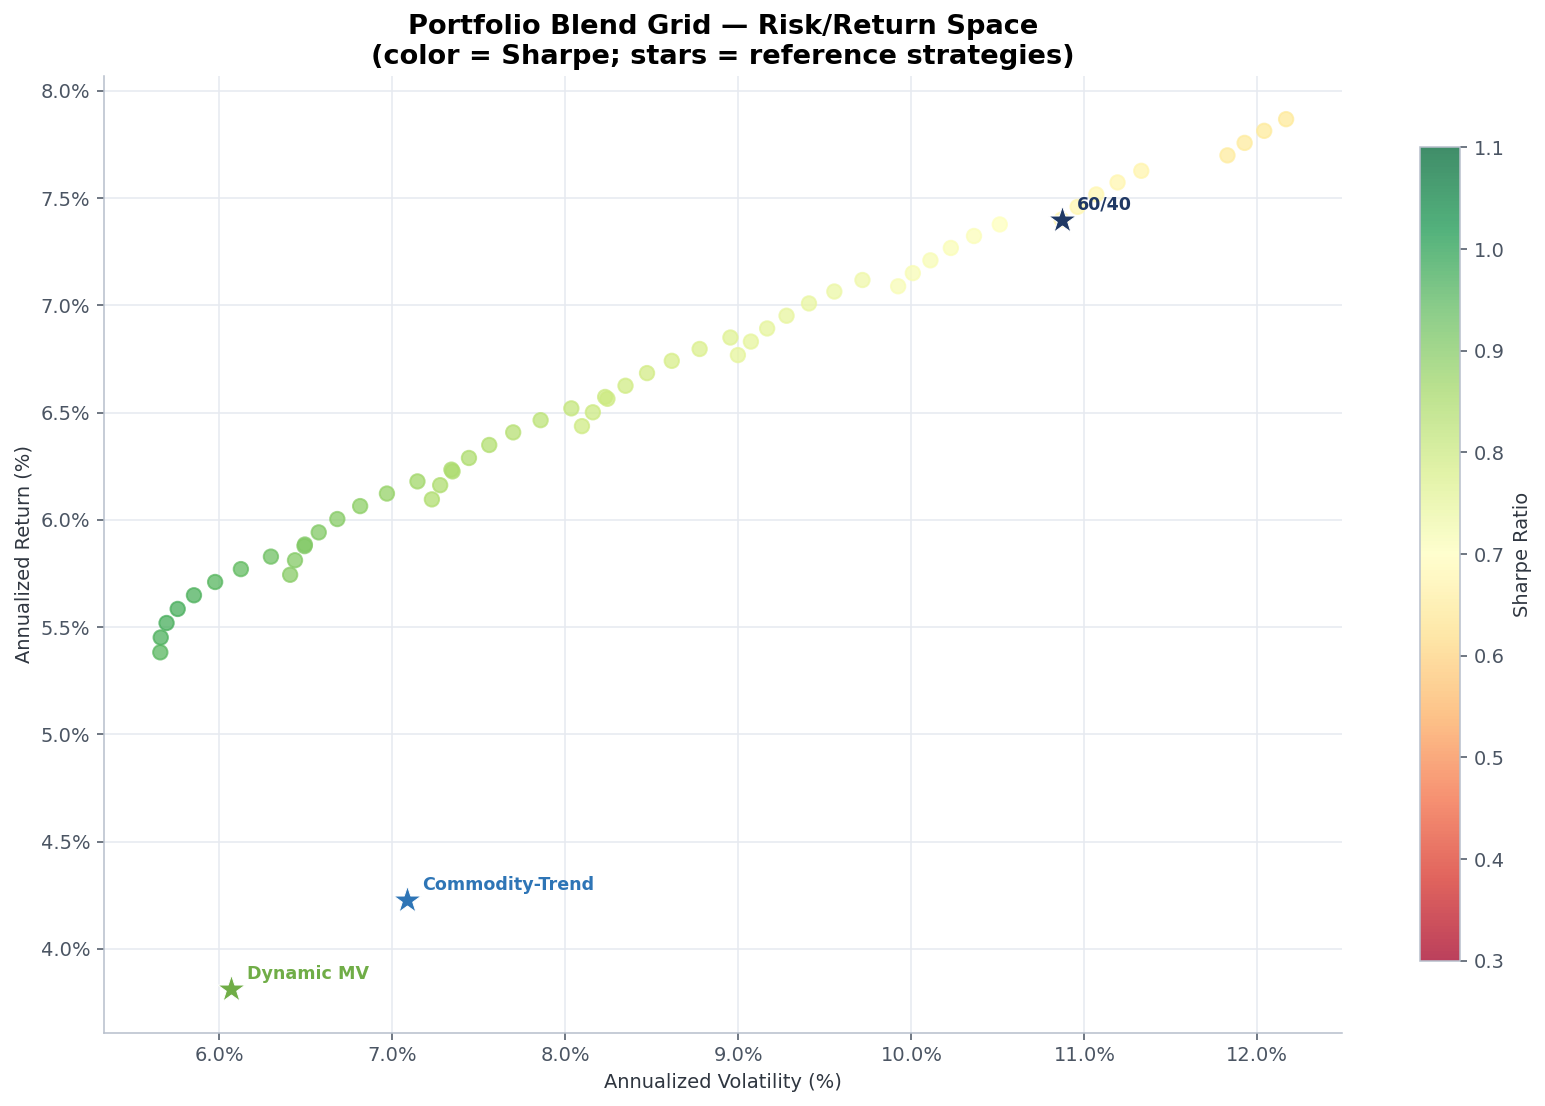

In [6]:
bench_m = compute_metrics('60/40',             bench_ret)
trend_m = compute_metrics('Commodity-Trend',   trend_ret)
dyn_m   = compute_metrics('Dynamic MV',        q3_dyn['ret_dynamic_mv_3a'].dropna())

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(
    grid['Ann. Vol'] * 100, grid['Ann. Return'] * 100,
    c=grid['Sharpe'], cmap='RdYlGn', s=55, alpha=0.75, vmin=0.3, vmax=1.1, zorder=2)
cbar = plt.colorbar(sc, ax=ax, shrink=0.85)
cbar.set_label('Sharpe Ratio')

anchors = [
    (bench_m, '60/40',           '#1F3864'),
    (trend_m, 'Commodity-Trend', '#2E75B6'),
    (dyn_m,   'Dynamic MV',      '#70AD47'),
]
if 'Static MV' in q3_strat.index:
    row = q3_strat.loc['Static MV']
    anchors.append(({'Ann. Vol': row['Ann. Vol'], 'Ann. Return': row['Ann. Return']},
                    'Static MV', '#FF7F0E'))

for m, label, color in anchors:
    ax.scatter(m['Ann. Vol'] * 100, m['Ann. Return'] * 100,
               color=color, s=220, marker='*', zorder=5,
               edgecolors='white', linewidth=0.5)
    ax.annotate(label, (m['Ann. Vol'] * 100, m['Ann. Return'] * 100),
                textcoords='offset points', xytext=(8, 5),
                fontsize=9, fontweight='bold', color=color)

ax.set_xlabel('Annualized Volatility (%)')
ax.set_ylabel('Annualized Return (%)')
ax.set_title('Portfolio Blend Grid — Risk/Return Space\n'
             '(color = Sharpe; stars = reference strategies)')
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.savefig(SIZING_DIR / 'blend_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

The chart shows you can get more return AND less risk than 60/40 by shifting allocation toward bonds + small trend sleeve. That's the green region of the cloud, to the left of the 60/40 star.

## Section 3 — Value Added over 60/40

Improvement in Sharpe, Calmar, and max drawdown relative to the 60/40 baseline.

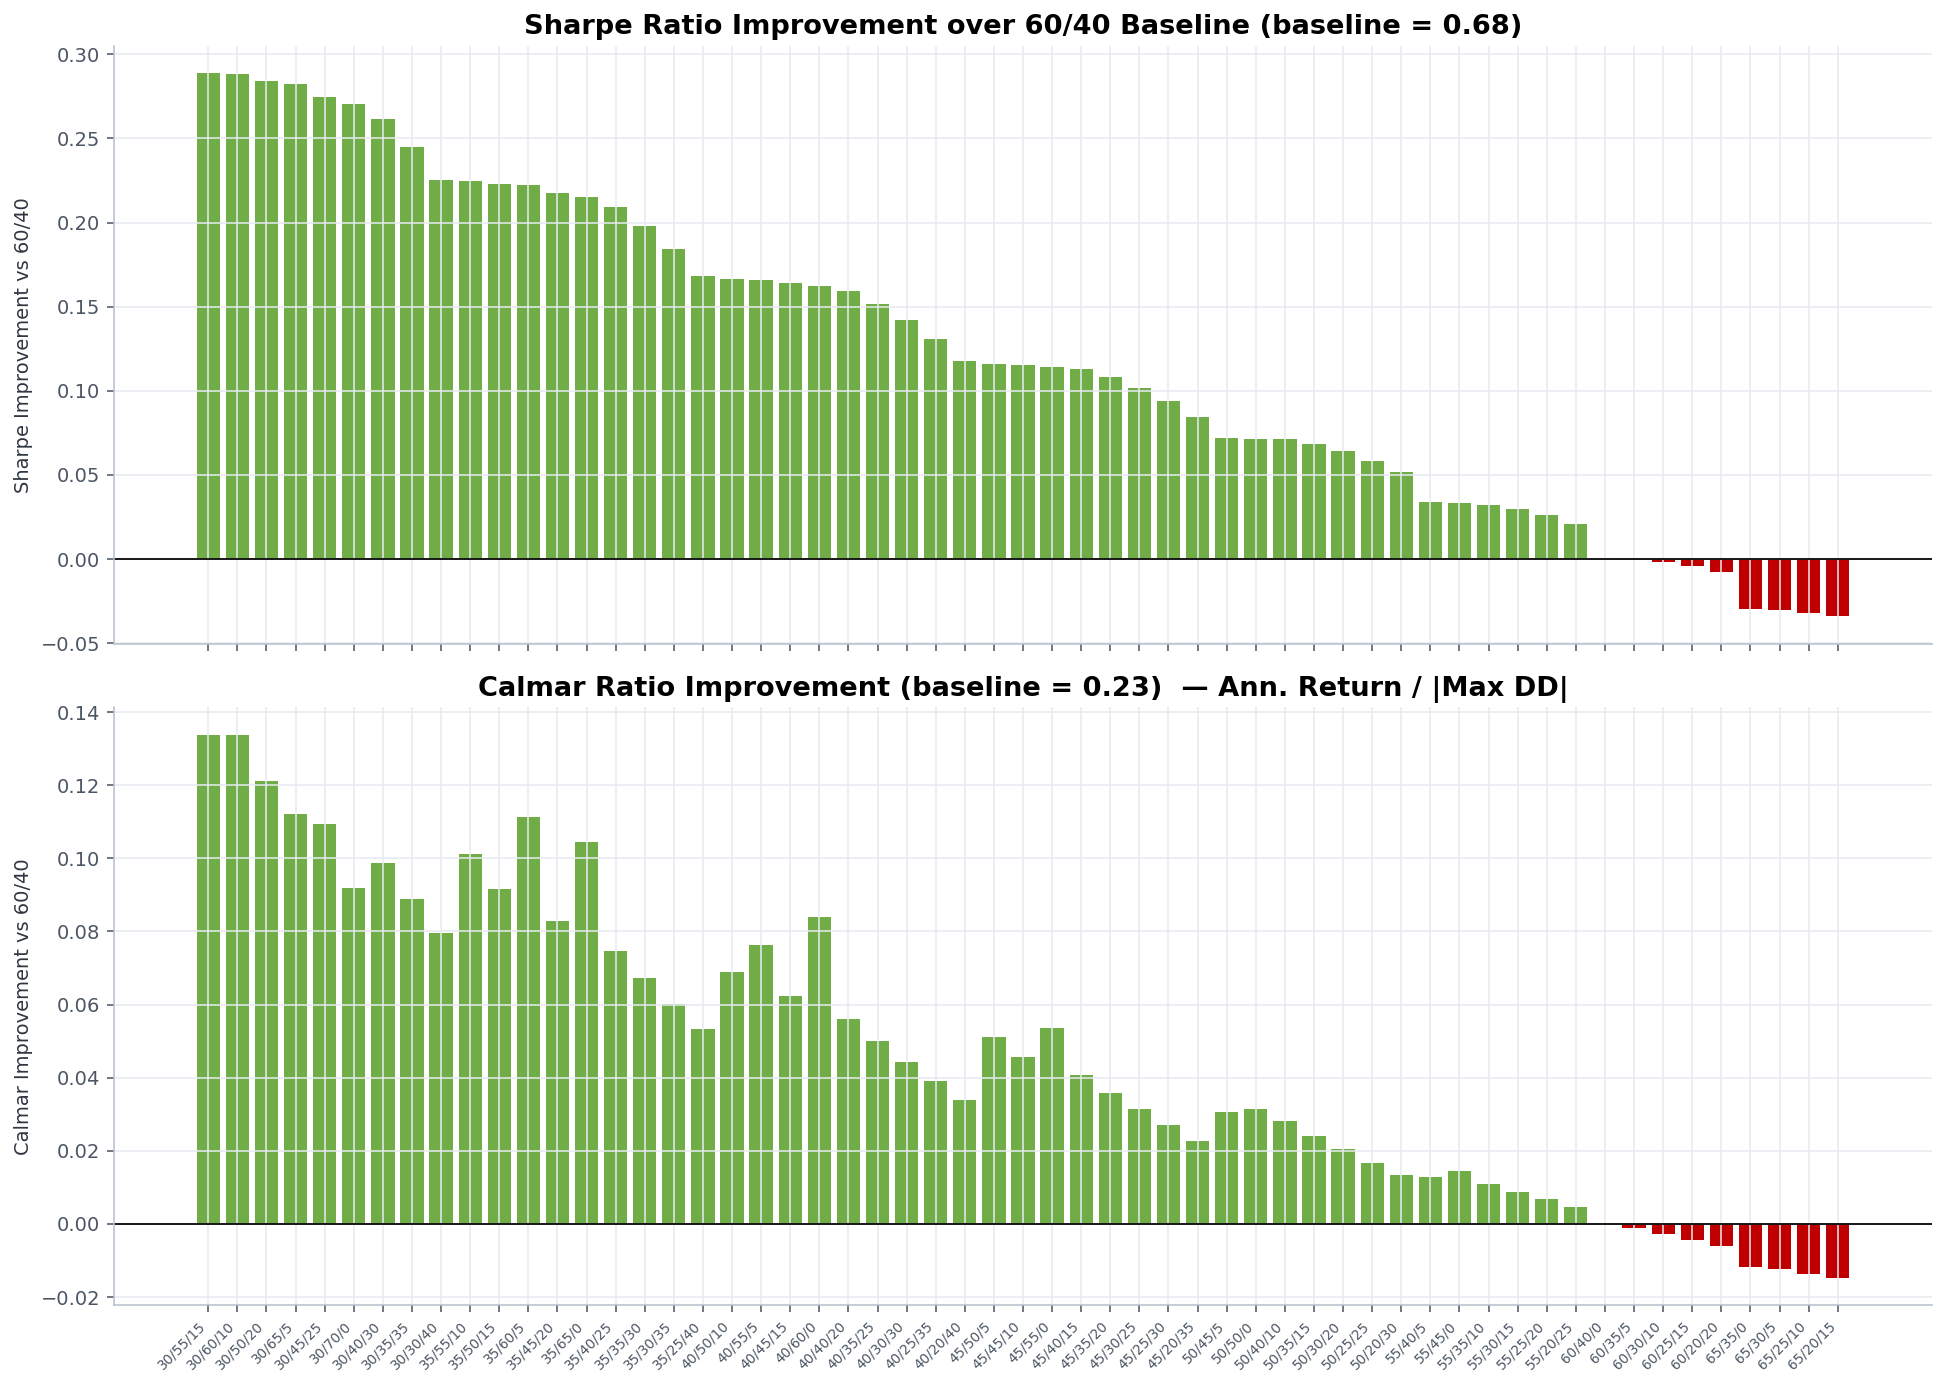

In [7]:
grid_sorted  = grid.sort_values('Sharpe', ascending=False)
base_sharpe  = bench_m['Sharpe']
base_calmar  = bench_m['Calmar']
sharpe_delta = grid_sorted['Sharpe'] - base_sharpe
calmar_delta = grid_sorted['Calmar'] - base_calmar

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Sharpe improvement
axes[0].bar(range(len(sharpe_delta)), sharpe_delta.values,
            color=['#70AD47' if v > 0 else '#C00000' for v in sharpe_delta], width=0.8)
axes[0].axhline(0, color='black', lw=0.9)
axes[0].set_ylabel('Sharpe Improvement vs 60/40')
axes[0].set_title(f'Sharpe Ratio Improvement over 60/40 Baseline (baseline = {base_sharpe:.2f})')

# Calmar improvement
axes[1].bar(range(len(calmar_delta)), calmar_delta.values,
            color=['#70AD47' if v > 0 else '#C00000' for v in calmar_delta], width=0.8)
axes[1].axhline(0, color='black', lw=0.9)
axes[1].set_ylabel('Calmar Improvement vs 60/40')
axes[1].set_title(f'Calmar Ratio Improvement (baseline = {base_calmar:.2f})  '
                  '— Ann. Return / |Max DD|')
axes[1].set_xticks(range(len(sharpe_delta)))
axes[1].set_xticklabels(sharpe_delta.index, rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig(SIZING_DIR / 'blend_improvement.png', dpi=150, bbox_inches='tight')
plt.show()

The bar height is the difference vs. the 60/40 baseline. These charts show that when you purely optimize for Sharpe or Calmar, you are mostly being rewarded for cutting drawdowns, not for generating reutnr.

## Section 4 — Regime-Conditional Sharpe

Does the improvement hold across all yield-curve regimes, or is it concentrated in specific regimes?

In [9]:
joint_r = daily[['spxt_return', 'luattruu_return',
                  'method1_strategy_return', 'benchmark_strategy_return']].join(
    regimes_raw.rename('regime'), how='inner')
joint_regime = joint_r['regime']

top5_labels = list(grid.sort_values('Sharpe', ascending=False).head(5).index)
cond_sharpe = {}

for label in top5_labels:
    row = grid.loc[label]
    ret = (row['Stock %'] / 100 * joint_r['spxt_return']
           + row['Bond %']  / 100 * joint_r['luattruu_return']
           + row['Trend %'] / 100 * joint_r['method1_strategy_return'])
    cond_sharpe[label] = regime_sharpe(ret, joint_regime)

cond_sharpe['60/40 (baseline)'] = regime_sharpe(
    joint_r['benchmark_strategy_return'], joint_regime)

cond_df = pd.DataFrame(cond_sharpe).T
cond_df.to_csv(SIZING_DIR / 'blend_regime_conditional.csv')

display(cond_df.style
        .format('{:.2f}')
        .background_gradient(cmap='RdYlGn', axis=None, vmin=-0.3, vmax=2.5)
        .set_caption('Regime-Conditional Sharpe — Top 5 Blends vs 60/40 Baseline'))

,Bull Steepener,Bull Flattener,Bear Steepener,Bear Flattener,Steepener Twist,Flattener Twist
30/55/15,1.39,1.06,2.76,0.23,0.23,1.64
30/60/10,1.33,1.05,2.93,0.22,0.29,1.61
30/50/20,1.45,1.06,2.57,0.24,0.18,1.67
30/65/5,1.25,1.03,3.08,0.21,0.34,1.56
30/45/25,1.50,1.06,2.37,0.24,0.12,1.68
60/40 (baseline),0.76,1.19,1.80,0.24,-0.09,0.41


The top blends beat 60/40 in 5 out of 6 regimes — the improvement is broad-based, not concentrated. The one exception is Bull Flattener, where 60/40's higher equity exposure benefits it. Bear Flattener and Steepener Twist are low for everyone (bad environments across the board). The outperformance is biggest in Bear Steepener because bonds rally hard when rates fall fast, which the bond-heavy blends benefit from enormously.

## Section 5 — Comparison to Dynamic MV

How much of the dynamic optimizer's benefit can a simple fixed blend capture?

In [10]:
metrics_cols = ['Ann. Return', 'Ann. Vol', 'Sharpe', 'Max DD', 'Calmar', 'Sortino']
top10 = grid.sort_values('Sharpe', ascending=False).head(10)[metrics_cols]

ref_metrics = {}
for label, ret_s in [
    ('60/40 (baseline)',     bench_ret),
    ('Commodity-Trend',      trend_ret),
    ('Dynamic MV (3-Asset)', q3_dyn['ret_dynamic_mv_3a'].dropna()),
]:
    m = compute_metrics(label, ret_s)
    ref_metrics[label] = {k: m[k] for k in metrics_cols}

combined = pd.concat([top10, pd.DataFrame(ref_metrics).T])
combined.to_csv(SIZING_DIR / 'blend_summary_vs_reference.csv')

fmt = {'Ann. Return': '{:.1%}', 'Ann. Vol': '{:.1%}', 'Sharpe': '{:.2f}',
       'Max DD': '{:.1%}', 'Calmar': '{:.2f}', 'Sortino': '{:.2f}'}
display(combined.style.format(fmt)
        .set_caption('Top 10 Blends vs Reference Strategies\n'
                     '(Dynamic MV = optimizer benchmark; fixed blends = simpler implementation)'))

,Ann. Return,Ann. Vol,Sharpe,Max DD,Calmar,Sortino
30/55/15,5.6%,5.8%,0.97,-15.5%,0.36,1.26
30/60/10,5.5%,5.7%,0.97,-15.3%,0.36,1.27
30/50/20,5.6%,5.9%,0.97,-16.3%,0.35,1.26
30/65/5,5.5%,5.7%,0.96,-16.1%,0.34,1.26
30/45/25,5.7%,6.0%,0.96,-17.0%,0.34,1.24
30/70/0,5.4%,5.7%,0.95,-16.9%,0.32,1.25
30/40/30,5.8%,6.1%,0.94,-17.7%,0.33,1.22
30/35/35,5.8%,6.3%,0.93,-18.5%,0.32,1.20
30/30/40,5.9%,6.5%,0.91,-19.2%,0.31,1.17
35/55/10,5.9%,6.5%,0.91,-17.9%,0.33,1.17


From these results, the fixed bond heavy blends actually beat the Dynamic MV on sharpe but the MV starts 2 years later and misses the 2002 recovery period which could be affecting the results. The Dynamic MV's real selling point is that it still reducees the drawdown compared to the 60/40. 

A simple 30/55/15 fixed blend outperforms the dynamic optimizer on most metrics in this sample. However, the dynamic optimizer's advantage is that it doesn't require you to precommit to 30% equity as it adjusts over time. If the rate environment shifts (bonds stop outperforming), the optimizer can adapt while the fixed blend can't. 